In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.tree import plot_tree
from sklearn.linear_model import LogisticRegression
#importing libraries

In [53]:
data = pd.read_csv('Iris.csv')
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [54]:
data = data.drop(['Id'],axis=1)
data.head()
#removed unwanted columns

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [55]:
print(data.describe())

       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000


In [56]:
print(data.isnull().sum())
#no null values detected

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [57]:
data['Species'].value_counts()
#number of samples in each class of species

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

<Axes: >

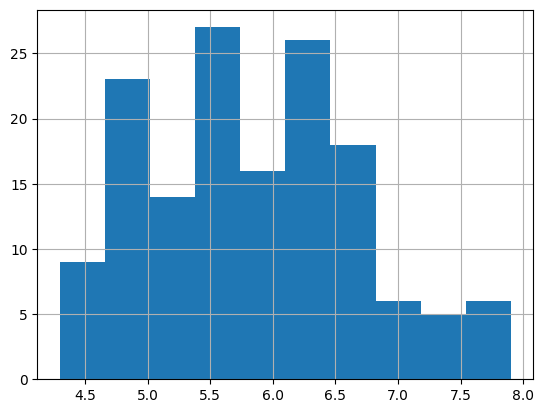

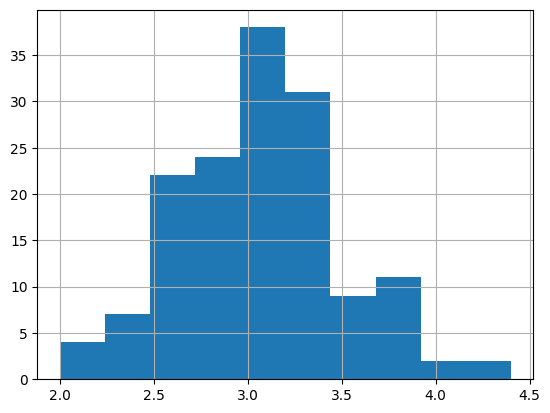

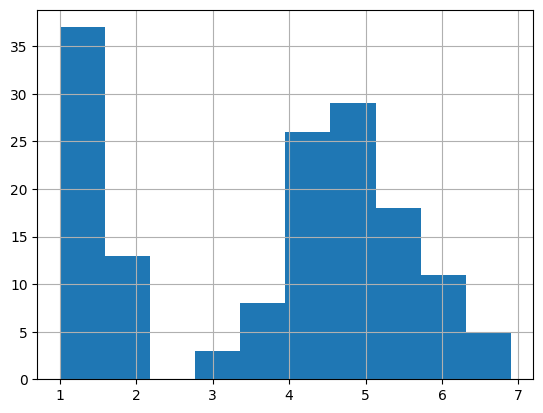

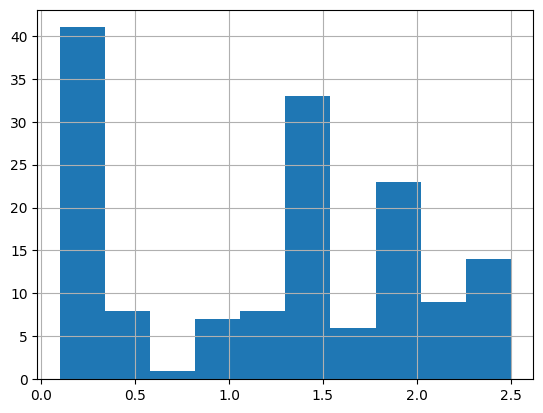

In [58]:
#histograms...
plt.figure()
data['SepalLengthCm'].hist()
plt.figure()
data['SepalWidthCm'].hist()
plt.figure()
data['PetalLengthCm'].hist()
plt.figure()
data['PetalWidthCm'].hist()
# count-> yaxis
#value-> xaxis

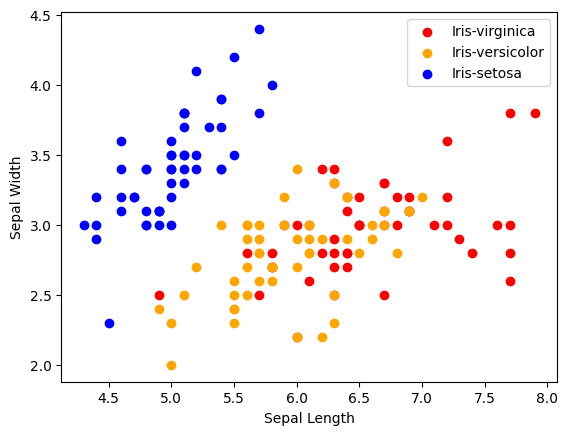

In [59]:
#scatterplots
colors = ['red', 'orange', 'blue']
species = ['Iris-virginica','Iris-versicolor','Iris-setosa']
for i in range(3):
    x = data[data['Species']==species[i]]
    plt.scatter(x['SepalLengthCm'],x['SepalWidthCm'],c=colors[i],label = species[i])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()

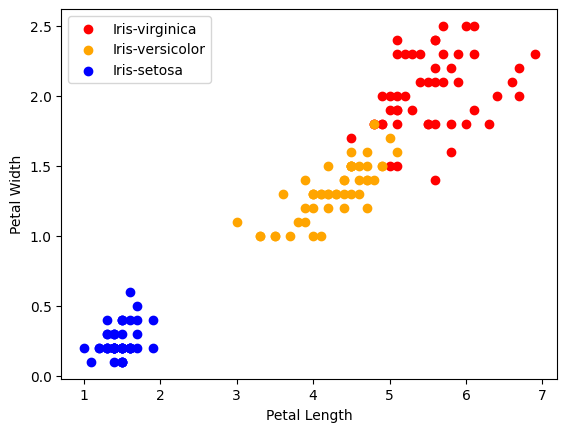

In [60]:
#scatterplots
colors = ['red', 'orange', 'blue']
species = ['Iris-virginica','Iris-versicolor','Iris-setosa']
for i in range(3):
    x = data[data['Species']==species[i]]
    plt.scatter(x['PetalLengthCm'],x['PetalWidthCm'],c=colors[i],label = species[i])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()

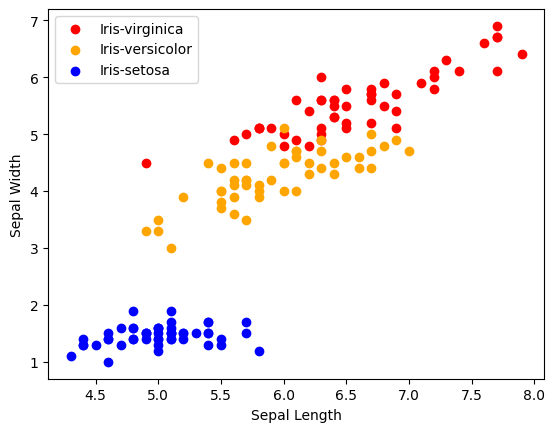

In [61]:
#scatterplots
colors = ['red', 'orange', 'blue']
species = ['Iris-virginica','Iris-versicolor','Iris-setosa']
for i in range(3):
    x = data[data['Species']==species[i]]
    plt.scatter(x['SepalLengthCm'],x['PetalLengthCm'],c=colors[i],label = species[i])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()

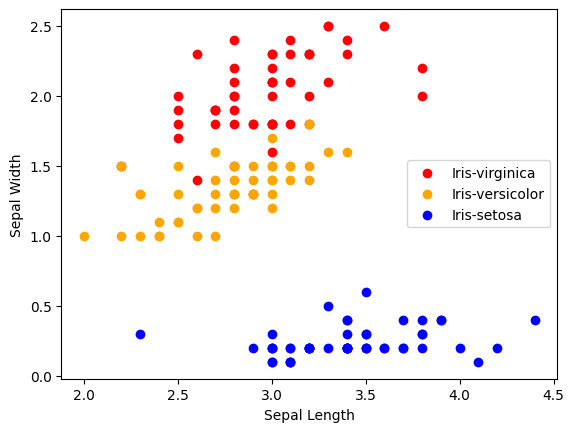

In [62]:
#scatterplots
colors = ['red', 'orange', 'blue']
species = ['Iris-virginica','Iris-versicolor','Iris-setosa']
for i in range(3):
    x = data[data['Species']==species[i]]
    plt.scatter(x['SepalWidthCm'],x['PetalWidthCm'],c=colors[i],label = species[i])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()

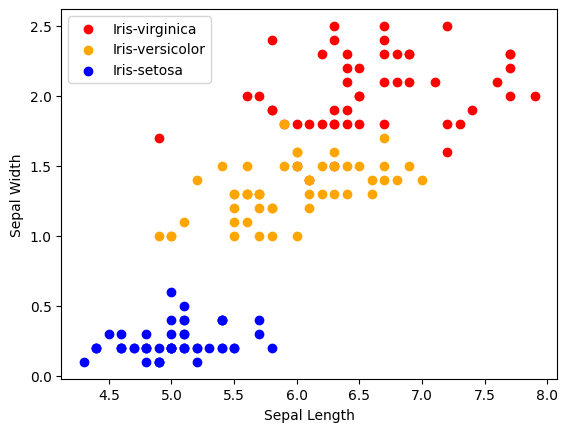

In [63]:
#scatterplots
colors = ['red','orange','blue']
species = ['Iris-virginica','Iris-versicolor','Iris-setosa']
for i in range(3):
    x = data[data['Species']==species[i]]
    plt.scatter(x['SepalLengthCm'],x['PetalWidthCm'],c=colors[i],label = species[i])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()

In [64]:
#commments
'''
setosa is comparitively easy to seperate
view petal length vs petal width shows the uniqueness of setosa
virginica length,width > versicolor, but some datapoints dont follow this
a simple model can be used to find setosa out of the dataset
learning is required to seperate virgnica and versicolor
'''

'\nsetosa is comparitively easy to seperate\nview petal length vs petal width shows the uniqueness of setosa\nvirginica length,width > versicolor, but some datapoints dont follow this\na simple model can be used to find setosa out of the dataset\nlearning is required to seperate virgnica and versicolor\n'

In [65]:
#correlation
data.corr(numeric_only=True)
'''+1 positively correlated as one increases the other increases
	-1 negatively correlated as one increases the other decreases
	0 no linear relation
    high positive correlation ---> features are redundant: both features dont add much unique signal
    model complexity increases unnecessarily
    negative correlations can teach tradeoffs
    in a dataset of performance vs power correlation might be -0.95'''

'+1 positively correlated as one increases the other increases\n\t-1 negatively correlated as one increases the other decreases\n\t0 no linear relation\n    high positive correlation ---> features are redundant: both features dont add much unique signal\n    model complexity increases unnecessarily\n    negative correlations can teach tradeoffs\n    in a dataset of performance vs power correlation might be -0.95'

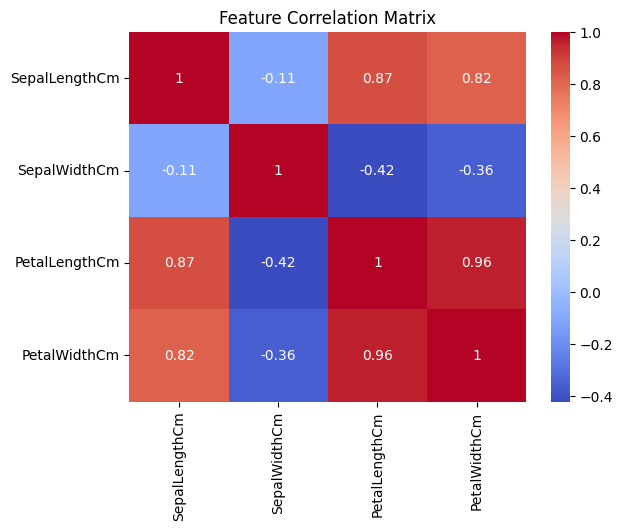

In [66]:
import seaborn as sns

corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [67]:
#commments
'''
petal width and petal length have unusually high correlation
since only 4 features are there in the dataset ill include all features for training irrespective of correlation
'''

'\npetal width and petal length have unusually high correlation\nsince only 4 features are there in the dataset ill include all features for training irrespective of correlation\n'

In [ ]:
from sklearn.preprocessing import LabelEncoder
l = LabelEncoder()

print(data['Species'].unique())#make sure columns are categorical

data['Species'] = l.fit_transform(data['Species'])#now encode

for cls, val in zip(l.classes_, l.transform(l.classes_)):#get mapping, class->encoded value
    print(f"{cls} → {val}")

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Iris-setosa → 0
Iris-versicolor → 1
Iris-virginica → 2


In [69]:
print(l.classes_)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [70]:
X = data.drop(['Species'],axis=1)
y = data['Species']

In [71]:
X.head() #before standardization:z-score = (currentvalue - mean) / std

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [72]:
X = (X - X.mean()) / X.std()

In [73]:
X.head() #after standardization

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.897674,1.028611,-1.336794,-1.308593
1,-1.139200,-0.124540,-1.336794,-1.308593
2,-1.380727,0.336720,-1.393470,-1.308593
3,-1.501490,0.106090,-1.280118,-1.308593
4,-1.018437,1.259242,-1.336794,-1.308593


In [74]:
# split for train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

DECISION TREE CLASSIFIER

In [75]:
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier(random_state=42)

In [76]:
model1.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [77]:
y_pred1 = model1.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("accuracy:", accuracy_score(y_test, y_pred1))
print("\nconfusion matrix:\n", confusion_matrix(y_test, y_pred1))
print("\nclassification report:\n", classification_report(y_test, y_pred1))

accuracy: 1.0

confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



LOGISTIC REGRESSION

In [79]:
model2 = LogisticRegression()
model2.fit(X_train,y_train)
y_pred2 = model2.predict(X_test)

In [80]:
print("accuracy:", accuracy_score(y_test, y_pred2))
print("\nconfusion matrix:\n", confusion_matrix(y_test, y_pred2))
print("\nclassification report:\n", classification_report(y_test, y_pred2))

accuracy: 1.0

confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



KNN ALGORITHM

In [81]:
from sklearn.neighbors import KNeighborsClassifier
model3 = KNeighborsClassifier(n_neighbors=5)
model3.fit(X_train,y_train)
y_pred3 = model3.predict(X_test)
print("accuracy:", accuracy_score(y_test, y_pred3))
print("\nconfusion matrix:\n", confusion_matrix(y_test, y_pred3))
print("\nclassification report:\n", classification_report(y_test, y_pred3))

accuracy: 1.0

confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



SVM-SVC

In [82]:
from sklearn.svm import SVC
model4 = SVC(kernel='rbf',C=1.0,gamma = 'scale')
model4.fit(X_train,y_train)
y_pred4 = model4.predict(X_test)
print("accuracy:", accuracy_score(y_test, y_pred4))
print("\nconfusion matrix:\n", confusion_matrix(y_test, y_pred4))
print("\nclassification report:\n", classification_report(y_test, y_pred4))

accuracy: 1.0

confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

